**KONUT FİYATLARININ TAHMİNİ**

Konut fiyat tahmini oldukça karmaşık ve çok sayıda parametrenin dikkate alınmasını gerektiren bir tahmin işlemidir.

Veri kümesinde 1460 konutun 81 adet kolon bulunmaktadır. Bu kolonların 79 tanesi konut özelliklerini temsil etmektedir. Konut özelliklerini temsil eden 79 kolonun 43 tanesi kategorik, 36 tanesi sayısal değer almaktadır. Konut özelliklerini temsil eden kolonlarda eksik veriler bulunmaktadır.

Bu çalışmanın amacı bu özellikler dikkate alınarak konut satış fiyatının(SalePrice) tahmin edilmesidir.

In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/test.csv
/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt


İlk adım olarak projede kullanacağımız Python’a ait olan kütüphanelerini import edelim.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.utils import shuffle

Pandas kütüphanesini import ederken pd kısaltması ile tanımladığımız için kodun her alanında artık pd ile çağırabilmemiz mümkündür. Üzerinde çalışacağım veri kümesi bir CSV dosyası olduğu için read_csv( ) metodu ile verimizi okuyarak head() metodu ile veri kümemizin ilk 10 verisini görüntüleyelim.

In [44]:
train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
train_copy = train.copy()

train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


tail() metodu ile veri kümemizin son 10 verisini görüntüleyim.


In [45]:
train.tail(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1450,1451,90,RL,60.0,9000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,136000
1451,1452,20,RL,78.0,9262,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,New,Partial,287090
1452,1453,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,145000
1453,1454,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,84500
1454,1455,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,185000
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


Veri kümemizin ilk ve son 10 verisini görüntüledikten sonra verimizi daha iyi inceleyebilmek için sample() metodu ile verimizde yer alan rastgele 10 veriyi görüntüleyelim.

In [46]:
#veri kümesinden rastgele 10 verinin getirilmesi.
train_sample = train.sample(10)
train_sample

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
454,455,90,RL,63.0,9297,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Family,188000
186,187,80,RL,NaN,9947,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2009,WD,Normal,173000
1198,1199,20,RL,70.0,9100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,178000
12,13,20,RL,NaN,12968,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,144000
1130,1131,50,RL,65.0,7804,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,12,2009,WD,Normal,135000
489,490,180,RM,21.0,1526,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,86000
695,696,20,RL,54.0,13811,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,176000
666,667,60,RL,NaN,18450,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Abnorml,129000
1144,1145,190,RL,60.0,12180,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2010,WD,Normal,80000
357,358,120,RM,44.0,4224,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2007,WD,Normal,134000


info( ) metodu ile çalışılan veri kümesi içerisindeki dtype olarak bilinen veri tipleri ve kullanılan bellek hakkında bize bilgi vermektedir. Böylece veri kümesinin kolon sayısını ve veri tiplerini öğrenebiliriz.

In [47]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC


describe( ) metodu ile sayısal verilere sahip olan sütunların istatistiksel sonuçların hesaplanması sağlanır.

In [48]:
# NaN değerler hariç bir veri kümesinin dağılımının merkezi eğilimi, dağılımı, minimum ve maksimum aldığı değer.  
train_desc = train.describe().T
train_desc

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


**SATIŞ FİYATININ İNCELENMESİ**

Bu çalışmadaki asıl önemli nokta konutların satış fiyatı yani "SalePrice" kolonudur. Satış fiyatının ve diğer konut özelliklerinin birbiri ile olan korelasyonlarını yani birbirleriyle olan bağlılıklarını incelemek bize özellik seçiminde yardımcı olacaktır.

"SalePrice" kolonunu biraz inceleyelim.


In [49]:
#konut fiyatlarının istatiksel özeti

salePrice_desc = train['SalePrice'].describe().T
salePrice_desc 

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Text(0.5, 1.0, 'SalePrice Dağılımı')

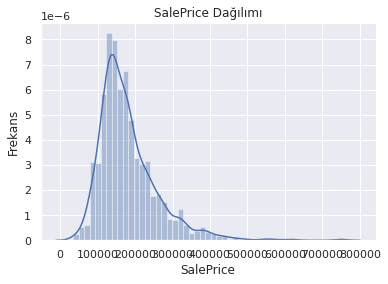

In [50]:
sns.distplot(train['SalePrice'])
plt.ylabel('Frekans')
plt.title('SalePrice Dağılımı')

skew() metodu veri kümesinin çarpıklığını hesaplamaktadır. Çarpıklık; 

![](http://media.geeksforgeeks.org/wp-content/uploads/skewness.jpg)

formulü ile hesaplanır. 

* çarpıklık = 0: normal dağılım
* çarpıklık > 0: dağılımın sol kuyruğunda daha fazla ağırlık
* çarpıklık < 0: dağılımın sağ kuyruğunda daha fazla ağırlık 

Basıklık kavramı bir reel değerli rassal değişken için olasılık dağılımının, grafik gösteriminden tanımlanarak ortaya çıkarılan bir kavram olan, sivriliği veya basıklığı özelliğinin ölçümüdür.






In [51]:
#Çarpıklık ve basıklık

print("Çarpıklık: %f" % train['SalePrice'].skew())
print("Basıklık: %f" % train['SalePrice'].kurt())

Çarpıklık: 1.882876
Basıklık: 6.536282


corr() metodu veri kümesinde yer alan özeliklerin korelasyon matrisini oluşturur(Sadece sayılsal değer alan özellikler için). Korelasyon iki rassal değişken arasındaki doğrusal ilişkinin yönünü ve gücünü belirtir.

In [52]:
# korelasyon matrisi

corrmat = train.corr()
corrmat

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


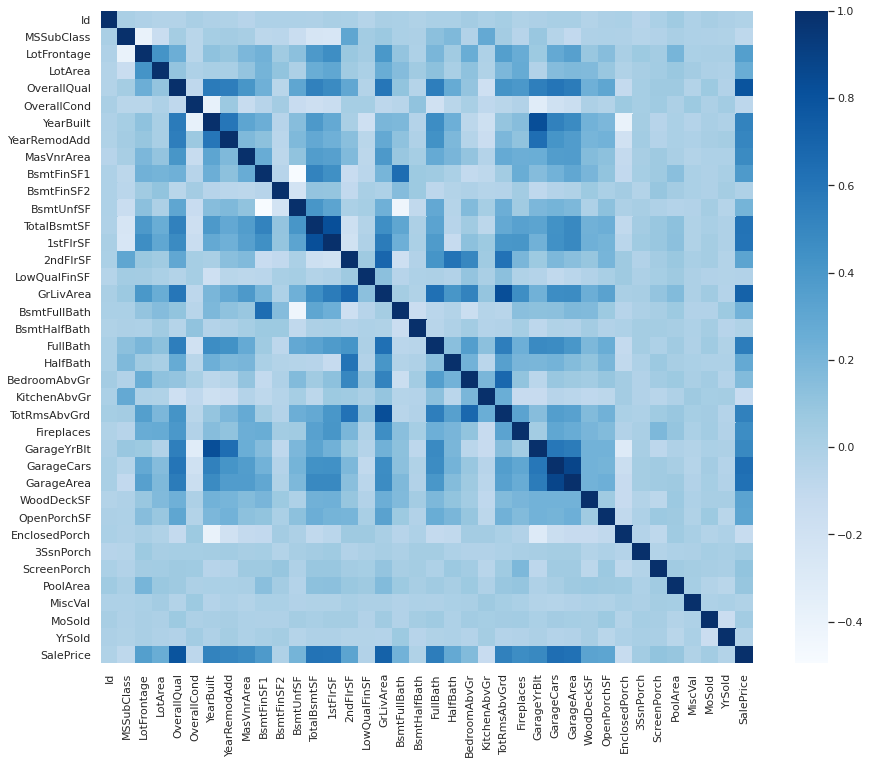

In [53]:
# korelasyon matrisinin görselleştirilmesi

plt.subplots(figsize=(15,12))
sns.heatmap(corrmat, vmax=1, cmap="Blues", square=True)

Bu çalışmada önemli olan nokta konutların satış fiyatı(SalePrice) olduğu için bir de satış fiyatının diğer özelliklerle olan korelasyonuna bakalım.

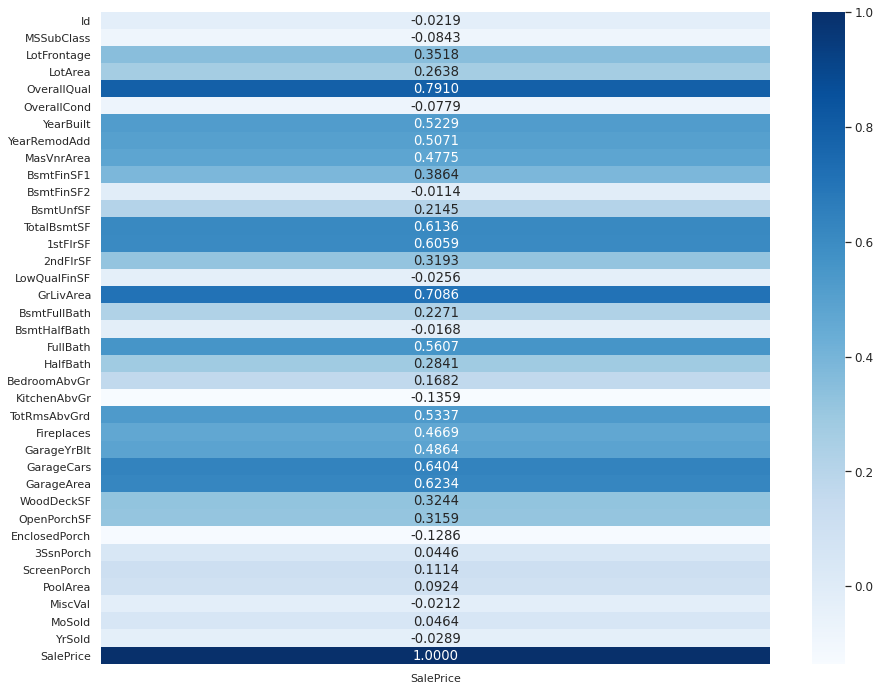

In [54]:
#"SalePrice" ve diğer konut özelliklerinin korelasyon matrisinin oluşturulması

salePrice = train["SalePrice"]
corr_salePrice = train.corrwith(salePrice, axis=0)
corr_salePrice = pd.DataFrame(corr_salePrice)
corr_salePrice.rename (columns = {0: 'SalePrice'}, inplace = True)

#Oluşturulan korelasyon matrisinin görselleştirilmesi
plt.subplots(figsize=(15,12))
sns.set(font_scale=1.1)
sns.heatmap(corr_salePrice, vmax=1, cmap="Blues",fmt='.4f',annot=True)

Yukarıda yer alan korelasyon grafiğinde satış fiyatının ve diğer konut özelliklerinin korelasyonu görülmektedir. Buradan yola çıkarak bir konutun satış fiyatını 0.5'ten büyük bir korelasyonu olan özelliklerin  ‘OverallQual’, 'YearBuilt', ‘TotalBsmtSF’, ‘1stFlrSF’, 'GrLiArea', 'FullBath','TotRmsAbvGrd', ‘GarageCars’ ve ‘GarageArea’ olduğu görülmektedir.

Bu özelliklerin korelasyonuna bakacak olursak;

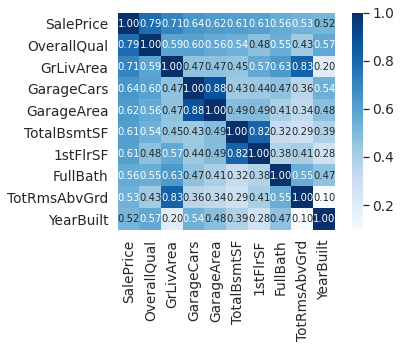

In [55]:
k = 10 # heatmap için değişken sayısı
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values, cmap="Blues")
plt.show()

Şimdi gelin konut fiyatlarının belirlenmesinde önemli olan bu özellikleri biraz yakından inceleyelim.

OverallQual kolonu konutun malzeme kalitesini ifade etmektedir. 1-10 arasında sayısal değer almaktadır.

(-0.5, 9.5, 0.0, 800000.0)

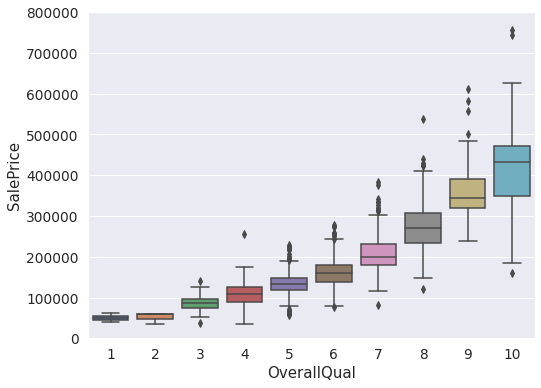

In [56]:
#box plot overallqual/saleprice
data = pd.concat([train['SalePrice'], train['OverallQual']], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x='OverallQual', y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000)

Kutu grafikleri, araştırmacıların ortalama değerleri, veri kümesinin dağılımını ve değişkenlik belirtilerini hızlı bir şekilde tanımlamasını, verilerin görsel bir özeti sağlayan grafiklerdir. Yukarıdaki grafikte aykırı değerler var gibi görünse de bu akırılık konutun sahip olduğu diğer özellikler ile bağlantılıdır.

Bir diğer önemli özelliğimiz de 'YearBuilt' yani konutun yapım yılı. Bu özelliğin kutu grafiği ise şu şekilde;

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111]),
 <a list of 112 Text major ticklabel objects>)

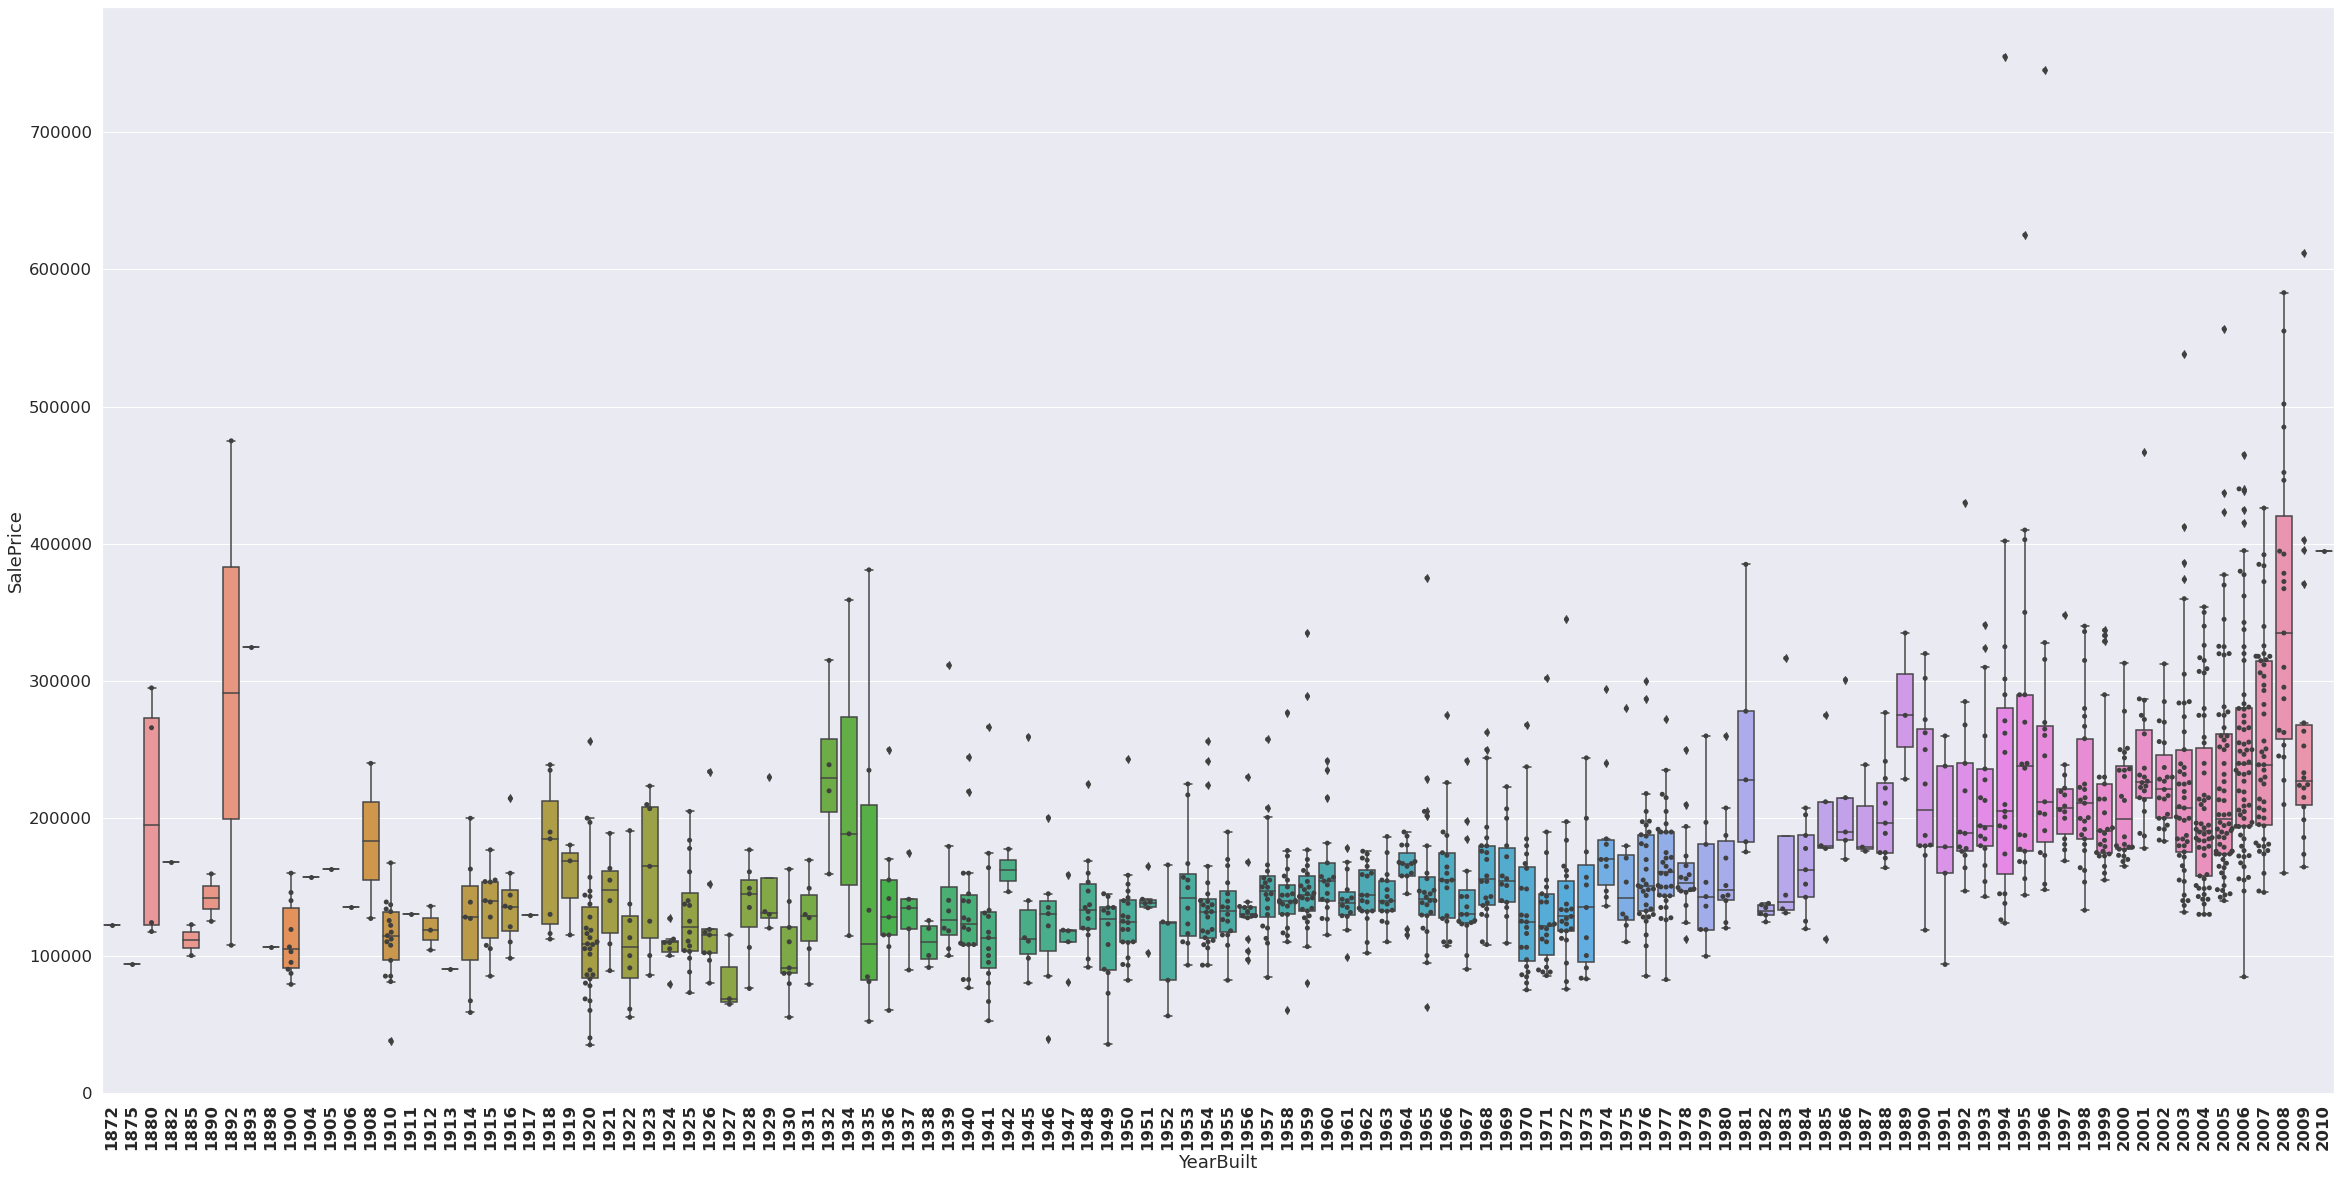

In [57]:
# YearBuild ve SalePrice boxlot
plt.figure(figsize=(40,20))
sns.set(font_scale=1.5)
sns.boxplot(x='YearBuilt', y="SalePrice", data=train)
sns.swarmplot(x='YearBuilt', y="SalePrice", data=train, color=".25")
plt.xticks(weight='bold',rotation=90)

Dağılım (scatter) diyagramı, iki farklı değişkenin arasındaki ilişkiyi belirlemek için kullanılan grafiklerden biridir. 

Satış fiyatı ve giriş katının toplam metrekaresi(TotalBsmtSF) arasındaki ilişki şu şekildedir;

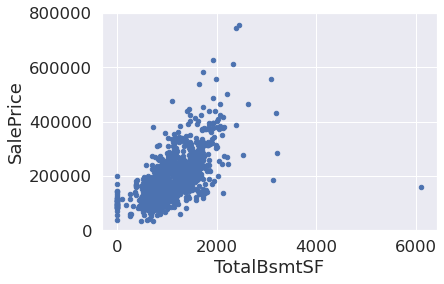

In [58]:
# TotalBsmtSF/salePrice Dağılım Grafiği 

data = pd.concat([train['SalePrice'], train['TotalBsmtSF']], axis=1)
data.plot.scatter(x='TotalBsmtSF', y='SalePrice', ylim=(0,800000));

Satış fiyatı ve konutun 1. katının metrekasi(1stFlrSF) arasındaki ilişki;

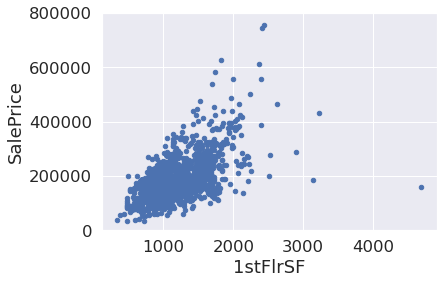

In [59]:
#1stFlrSF/salePrice Dağılım Grafiği 

data = pd.concat([train['SalePrice'], train['1stFlrSF']], axis=1)
data.plot.scatter(x='1stFlrSF', y='SalePrice', ylim=(0,800000));

Satış fiyatı ve konutun zemin üzerindeki toplam yaşam alanı(GrLivArea) arasındaki ilişki;

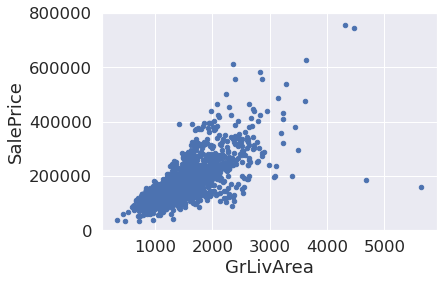

In [60]:
#GrLivArea/salePrice Dağılım Grafiği 

data = pd.concat([train['SalePrice'], train['GrLivArea']], axis=1)
data.plot.scatter(x='GrLivArea', y='SalePrice', ylim=(0,800000));

Satış fiyatı ile giriş katının toplam metrekaresi(TotalBsmtSF), konutun 1. katının metrekasi(1stFlrSF) ve konutun zemin üzerindeki toplam yaşam alanı(GrLivArea) arasında doğrusal bir ilişki bulunduğu dağılım grafiklerinde görülmektedir.

Satış fiyatı ve konutun tamamlanmış banyo sayısı (FullBath) arasındaki ilişki;

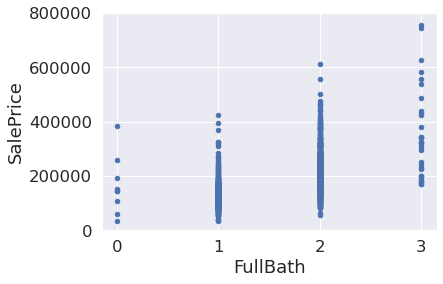

In [61]:
#FullBath/salePrice Dağılım Grafiği 

data = pd.concat([train['SalePrice'], train['FullBath']], axis=1)
data.plot.scatter(x='FullBath', y='SalePrice', ylim=(0,800000));

Satış fiyatı ve konutta yer alan toplam oda sayısı (TotRmsAbvGrd) arasındaki ilişki;

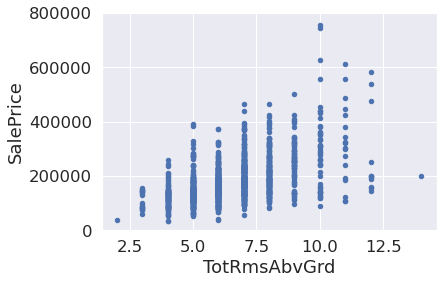

In [62]:
#TotRmsAbvGrd/salePrice Dağılım Grafiği 

data = pd.concat([train['SalePrice'], train['TotRmsAbvGrd']], axis=1)
data.plot.scatter(x='TotRmsAbvGrd', y='SalePrice', ylim=(0,800000));

Satış fiyatı ve konutun garajının araç kapasitesi(GarageCars) arasındaki ilişki;


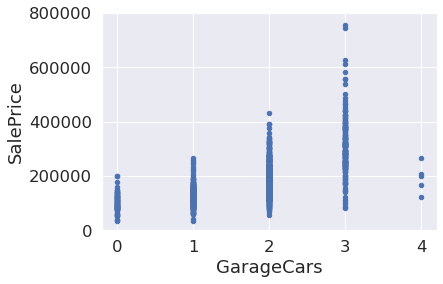

In [63]:
#GarageCars/salePrice Dağılım Grafiği 

data = pd.concat([train['SalePrice'], train['GarageCars']], axis=1)
data.plot.scatter(x='GarageCars', y='SalePrice', ylim=(0,800000));

Satış fiyatı ve konutun garajının  metrekaresi (GarageArea) arasındaki ilişki;

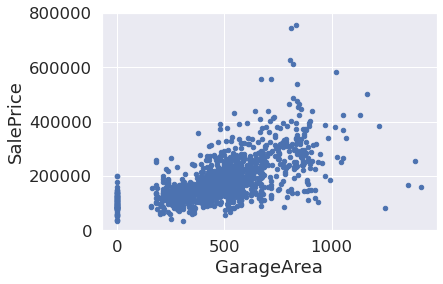

In [64]:
#GarageArea/salePrice Dağılım Grafiği 

data = pd.concat([train['SalePrice'], train['GarageArea']], axis=1)
data.plot.scatter(x='GarageArea', y='SalePrice', ylim=(0,800000));

Şimdide bu özelliklerin birbirleriyile olan ilişkilerini dağılım grafiğinde görelim;

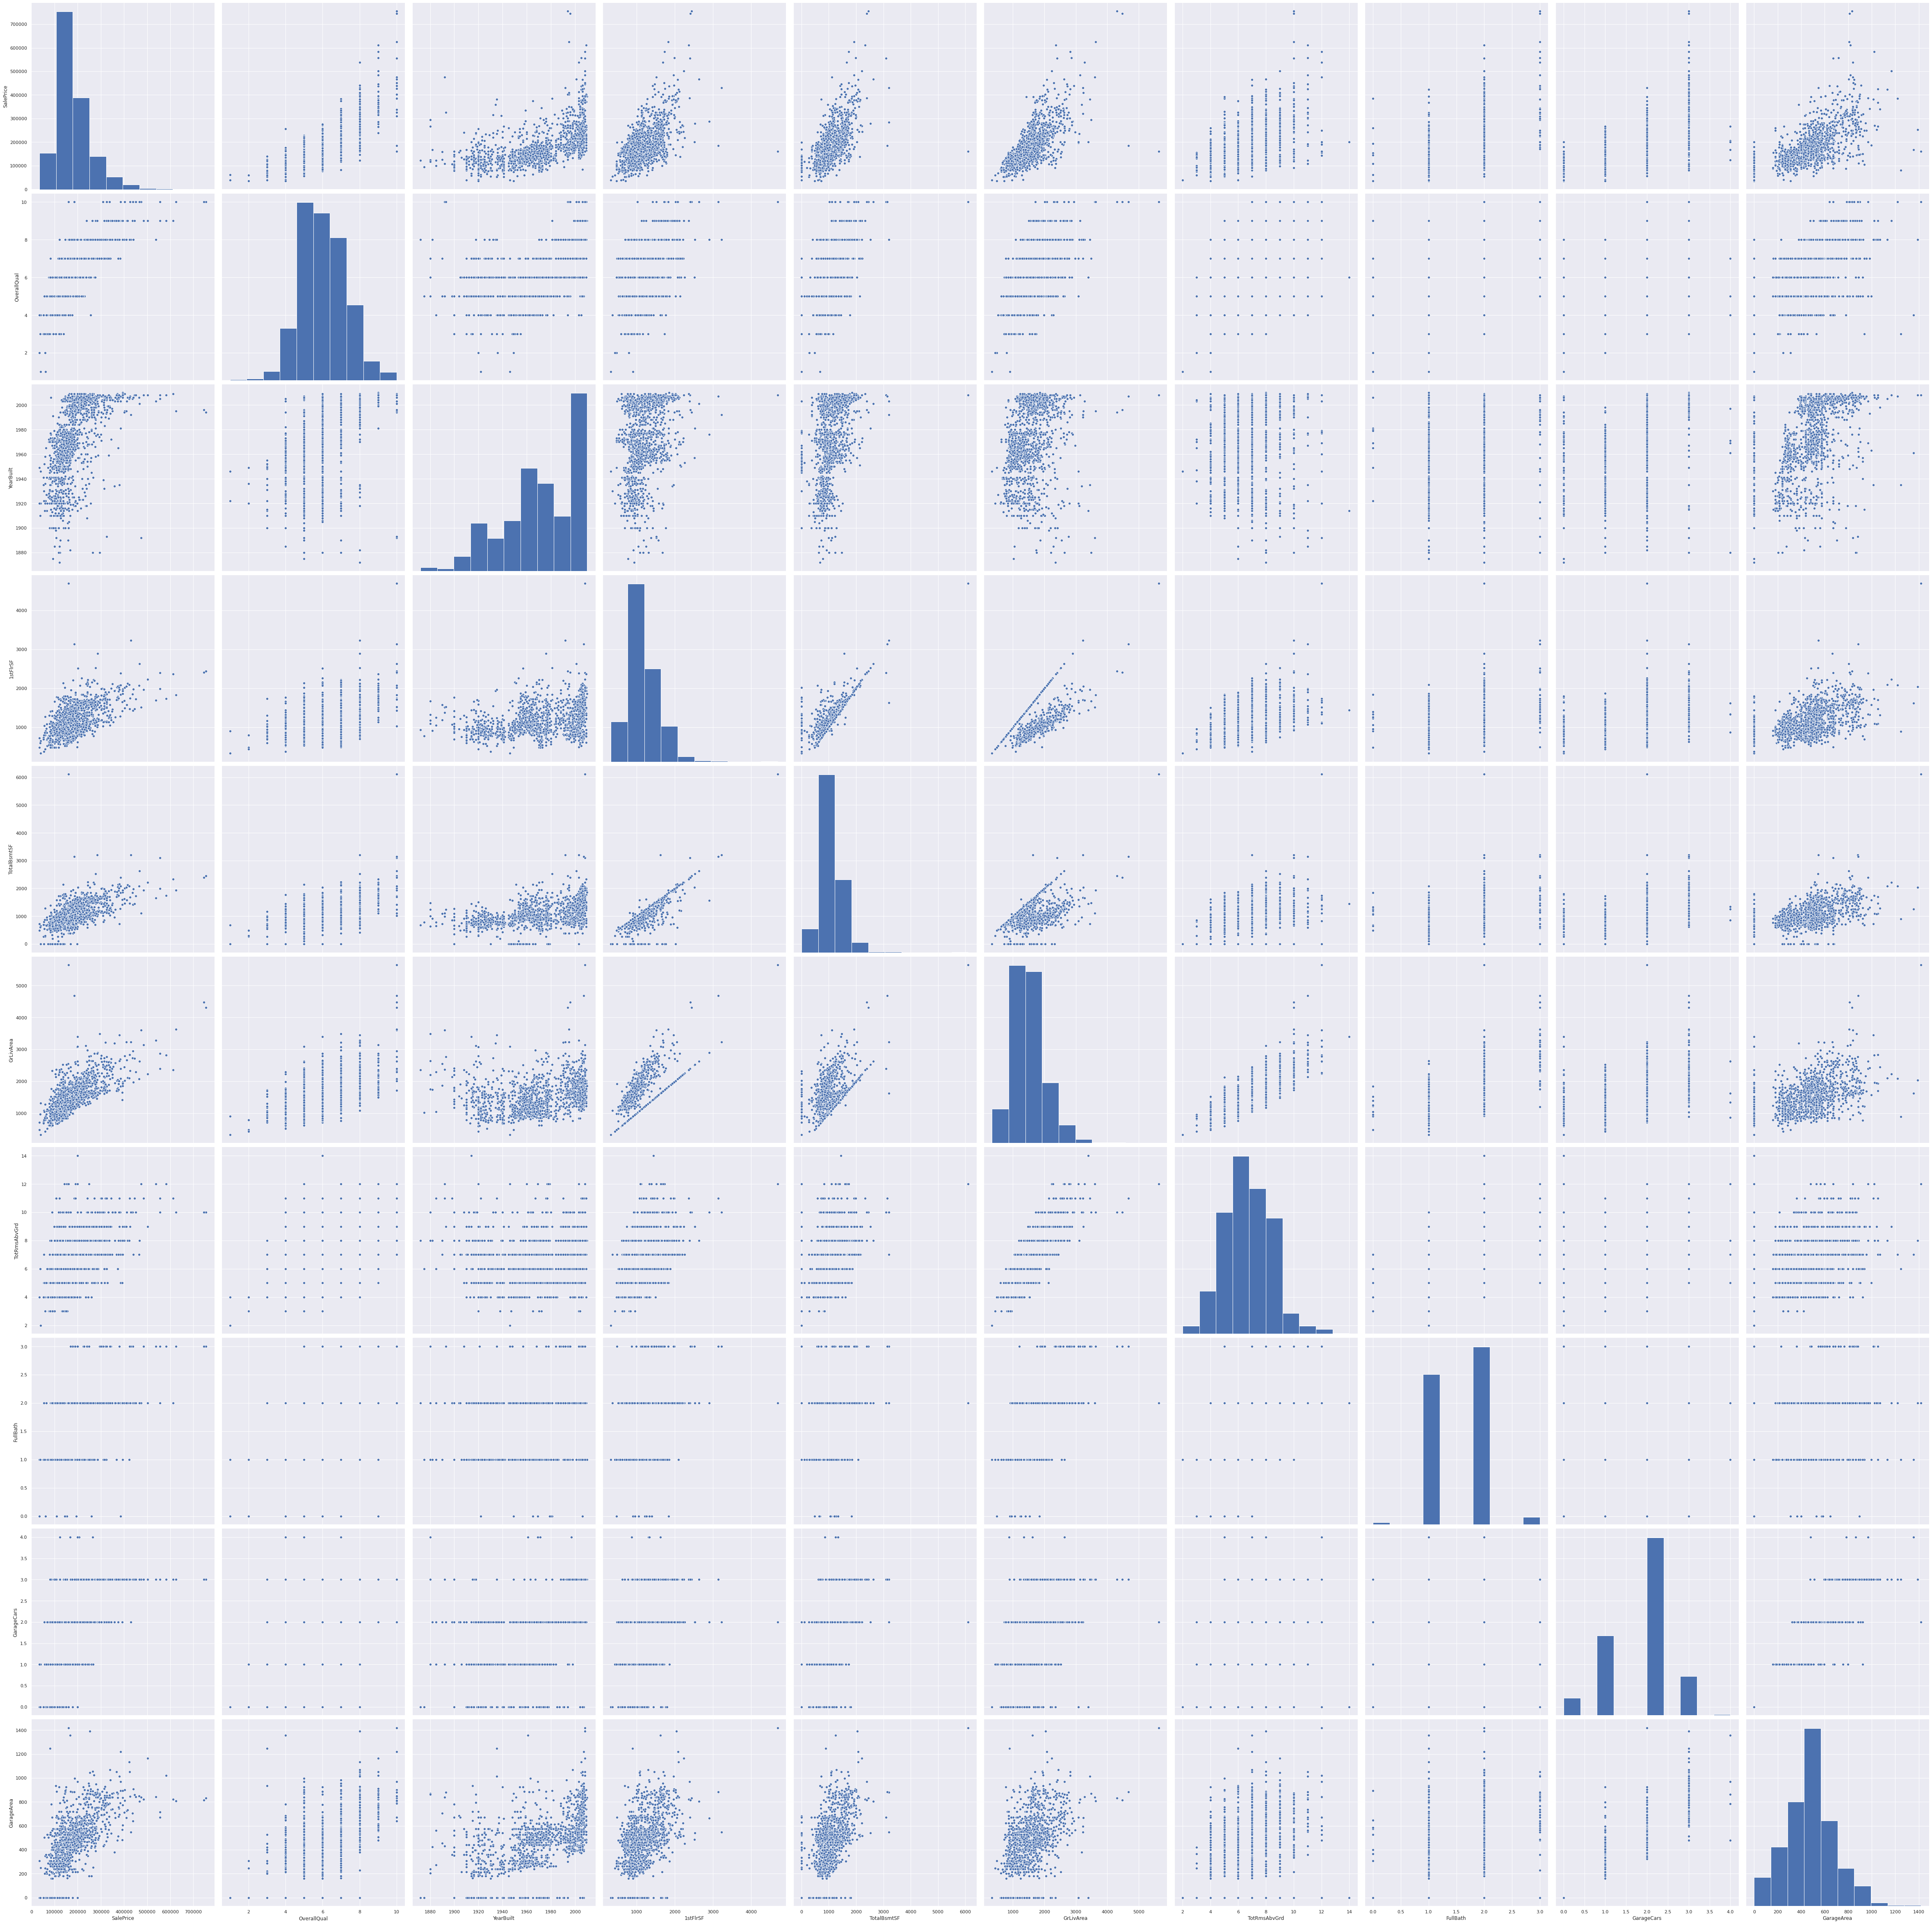

In [65]:
#scatterplot
sns.set()
cols = ['SalePrice', 'OverallQual', 'YearBuilt','1stFlrSF', 'TotalBsmtSF','GrLivArea' , 'TotRmsAbvGrd', 'FullBath',  'GarageCars', 'GarageArea']
sns.pairplot(train[cols], height = 6.5)
plt.show();

/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:2079: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


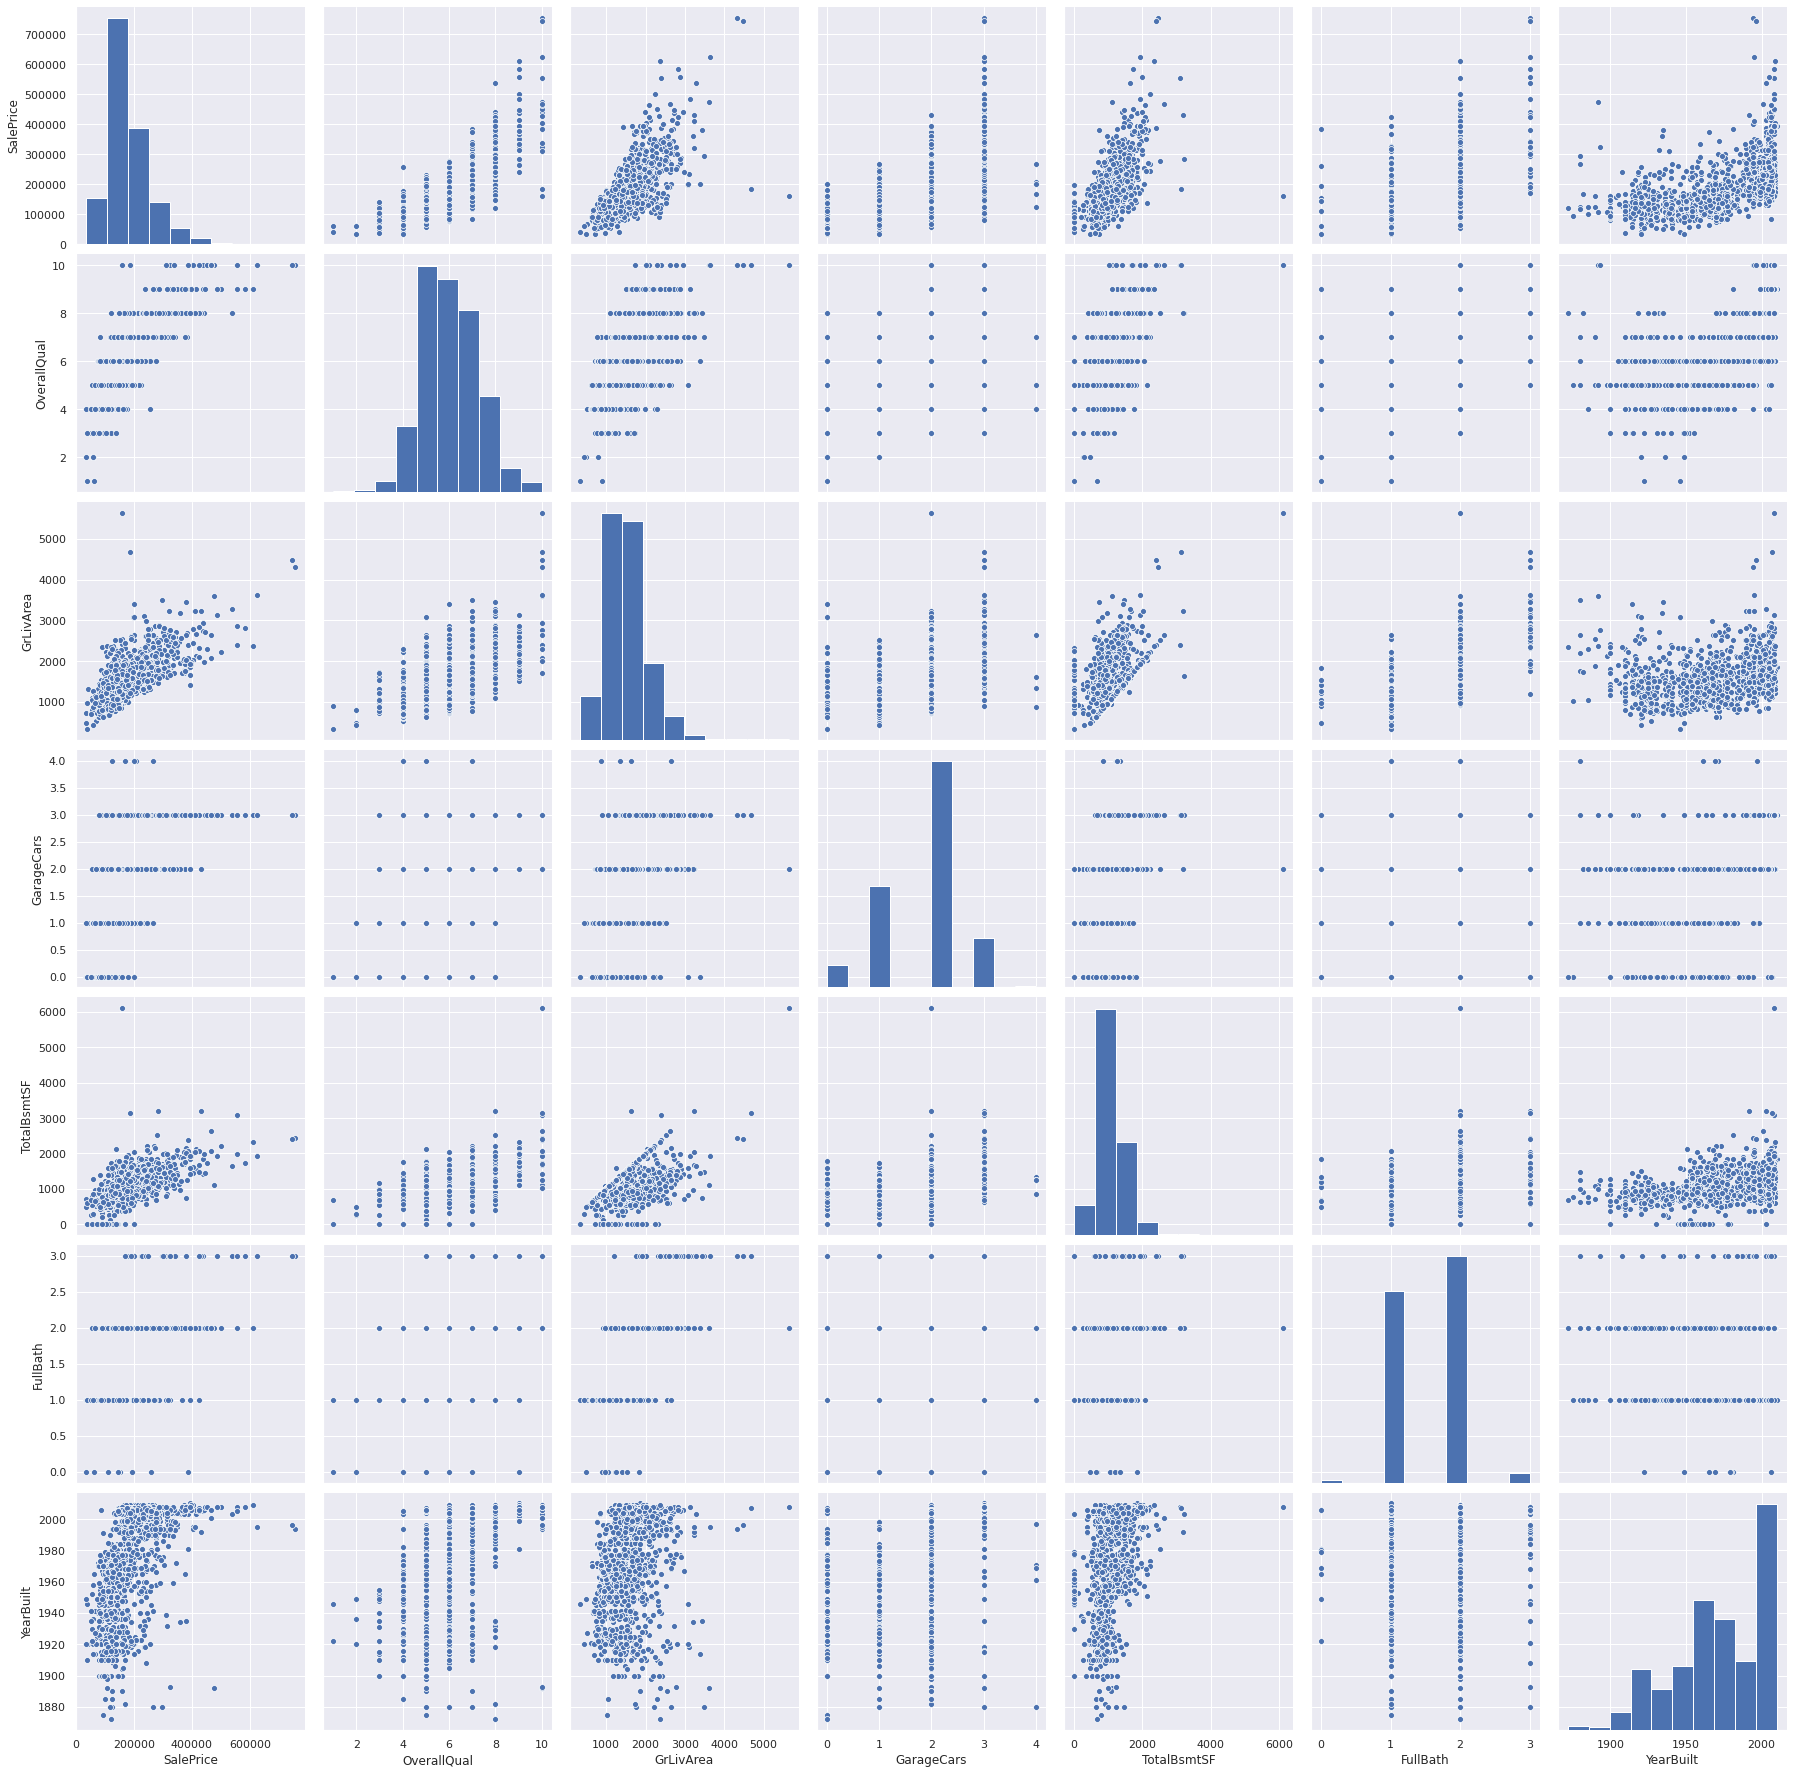

In [66]:
#scatterplot
sns.set()
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train[cols], size = 3.5)
plt.show();

Bu grafiklerin bazılarını zaten daha önce incelemiştik ancak bu mega dağılım grafiği bize değişken ilişkileri hakkında daha makul bir fikir vermektedir.

'TotalBsmtSF' ve 'GrLiveArea' arasında ki ilişkide, neredeyse bir sınır görevi gören noktaların doğrusal bir çizgi çizdiğini görebiliryoruz. Noktaların çoğunun bu çizginin altında kalması tamamen mantıklıdır çünkü bodrum alanları, yer üstü yaşam alanına eşit olabilir,fakat yer üstü yaşam alanından daha büyük bir bodrum beklenemez.


**EKSİK VERİLERİN İNCELENMESİ**

Eksik veri incelenen veri kümesindeki gözlemlerde eksiklik olması durumunu ifade etmektedir.  Veri ön işleme işlemlerinde karşımıza çıkan ciddi problemlerden biridir.

Öncelikle konut özelliklerini temsil eden kolonların hangisinde, ne kadar eksik veri olduğunu inceleyelim. Toplamda her sütun (özellik) için ne kadar NaN değer yer aldığını görmek istiyor iseniz sum() metodu ile sonucu ekranda görebilmeniz mümkündür.

In [67]:
total = train.isnull().sum().sort_values(ascending=False)
percent = (train.isnull().sum()/train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Toplam', 'Yüzde'])
missing_data = missing_data
missing_data

,Toplam,Yüzde
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
FireplaceQu,690,0.472603
...,...,...
CentralAir,0,0.000000
SaleCondition,0,0.000000
Heating,0,0.000000
TotalBsmtSF,0,0.000000


Eksik verileri görselleştirerek daha iyi gözlem yapabiliriz.

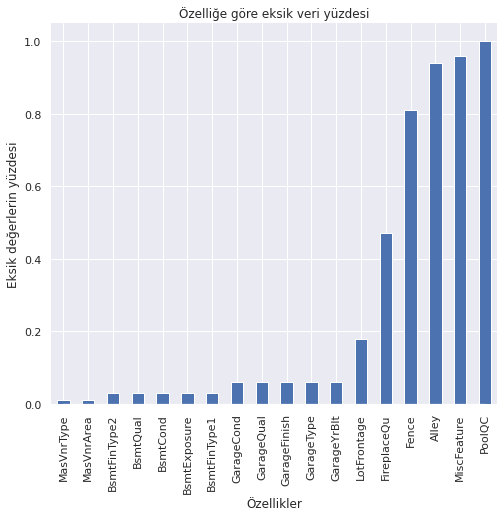

In [68]:
# Eksik verilerin görselleştirilmesi

f,ax = plt.subplots(figsize=(8, 7))
missing = round(train.isnull().mean(),2)
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar(color="b")

ax.set(ylabel="Eksik değerlerin yüzdesi")
ax.set(xlabel="Özellikler")
ax.set(title= "Özelliğe göre eksik veri yüzdesi")
sns.despine(trim=True, left=True)

Veri kümesininözellikleri incelendiği zaman, veri kümesinde yer alan kategorik değerler alan özelliklerde bulunan NaN değerler aslında eksik veri olmadığı ve bir anlam ifade ettiği,'NA' yani yok anlamına geldiği görülmektedir. 

Öncelikle veri kümesinde bu duruma sahip olan özelliklerideki eksik değerleri ‘None’ ifadesi ile tamamlamaya başlayalım. 

In [69]:
missing_categorical_cols = ["BsmtFinType2","BsmtQual","BsmtCond","BsmtExposure",
                            "BsmtFinType2","GarageCond", "GarageQual", "GarageFinish",
                            "GarageType","LotFrontage","FireplaceQu","Fence",
                            "Alley", "MiscFeature", "PoolQC"]

for col in missing_categorical_cols:
    col = train[col]
    for index in range(col.size):
        if col[index] is np.nan:
           col[index]= "None"
        else:
            continue

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Remove the CWD from sys.path while we load stuff.


Veri kümelerindeki bazı özelliklerdeki  eksiklikler başka bir değişkenle bağlantılı olup yapısal bir durumdan dolayı eksik olabilmektedir. 

Konutun garajının yapım yılı(GarageYrBlt) özelliğindeki eksik veriler de yapısal durumdan dolayı ortaya çıkmıştır. Bu özellik ‘None’ ifadesi ile doldurulan eksik verilerde bağlantılı olup garajı olmayan konutların garaj yapım yılı da bulunmamaktadır.

In [70]:
garageYrBlt = train["GarageYrBlt"]
for index in range(garageYrBlt.size):
    if np.isnan(garageYrBlt[index]):
        garageYrBlt[index] = 0.0
    else:
        continue
        

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


Eksik verinin 10 taneden az olduğu özellikleri Scikit-learn kütüphanesinin SimpleImputer modülünü kullanarak en sık kullanılan değer ile tamamlayalım.

Scikit-learn, Python programlama dilinde yazılmış bir makine öğrenme kütüphanesidir. SimpleImputer eksik değerlerin dönüştürülmesini sağlayan sklearn kütüphanesinden kullandığımız bir dönüştürücü modüldür.

missing_values parametresi ile dönüştürülmek istenen veriler belirlenmektedir.Daha sonraki parametre olan strategy parametresi sırasında ise 4 adet yer alan strateji türünden birisini seçerek hangi yönteme göre dönüştürüleceğine karar verilmektedir. Aşağıda bu stratejilere yer verilmektedir:

* “mean”  stratejisi, her sütun boyunca ortalama kullanılarak eksik değerlerin değiştirilmesini sağlar. Yalnızca sayısal verilerle kullanılabilir.

* “median” stratejisi, her sütun boyunca medyan kullanılarak eksik değerlerin değiştirilmesini sağlar. Yalnızca sayısal verilerle kullanılabilir.

* “most_frequent” stratejisi , her sütun boyunca en sık kullanılan değeri kullanılarak eksik değerlerin değiştirilmesini sağlar. String veya sayısal verilerle kullanılabilir.

* “constant” stratejisi, eksik değerleri fill_value ile değiştirin. String veya sayısal verilerle kullanılabilir.

Konutun bodrum katının değerlendirmesinde(BsmtFinType1) de bazı eksik veriler yer almaktadır. Bu eksik verileri en sık kullanılan değer ile tamamlayalım.

In [71]:
mean_f = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
train['BsmtFinType1'] = mean_f.fit_transform(train[['BsmtFinType1']])

Konutun elektrik sisteminde(Electrical) de bazı eksik veriler yer almaktadır. Bu eksik verileri de en sık kullanılan değer ile tamamlayalım


In [72]:
mean_f = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
train['Electrical'] = mean_f.fit_transform(train[['Electrical']])

Konutun duvar kaplaması kolonun bir adet eksik veri yer almaktadır. Onu veri kümesinde sıkça yer alan 'None' ifadesi ile tamamlayalım. Aynı konutun kaplamalı duvar metrekaresi verisi de eksikti, duvar kaplama tipini 'None' olarak tamaladığımız için o eksik veriyi de 0 olarak tamamlayalım.


In [73]:
#Duvar kaplama tipi
train['MasVnrType'] = train['MasVnrType'].fillna('None')

#Kaplamalı duvar metrekaresi
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

Bu eksik verilerimizi tamamladıktan sonra hangi özelliklerde eksik verimizin kaldığını kontrol edelim;

In [74]:
total = train.isnull().sum().sort_values(ascending=False)
percent = (train.isnull().sum()/train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Toplam', 'Yüzde'])

missing_data


,Toplam,Yüzde
LotFrontage,259,0.177397
SalePrice,0,0.000000
Foundation,0,0.000000
RoofMatl,0,0.000000
Exterior1st,0,0.000000
...,...,...
TotRmsAbvGrd,0,0.000000
Functional,0,0.000000
Fireplaces,0,0.000000
FireplaceQu,0,0.000000


Yapılan eksik veri tamamlama işlemlerinden sonra sadece konuta bağlı caddenin uzunluğu (LotFrontage) özelliğinde eksik veriler bulunmaktadır. Bu özellikteki eksik verilerin sayısı fazla olduğu için tahmine dayalı değer atama yöntemi kullanalım. 

Değer atama işlemi için uygulaması kolay gözetimli öğrenme algoritmalarından K-En Yakın Komşu (KNN) algoritmasından faydalanacağız ancak bundan önce kategorik özelliklerimizi sayısal özelliklere dönüştürmemiz gerekmekte. Bunun için get_dummies() metodunu  kullanacağız. 

In [75]:
train = train.drop("Id", axis='columns')

numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
categorial_cols = []

for col in train.columns:
    if train[col].dtype not in numeric_dtypes:
       categorial_cols.append(col)
    else:
        continue

train_dummy = pd.get_dummies(train[categorial_cols])
train = train.drop(categorial_cols, axis='columns')
train  = pd.concat([train,train_dummy], axis=1)

train.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,0,0,1,0,0,0,0,1,0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,1,0,0,0,0,1,0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,0,0,1,0,0,0,0,1,0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,0,0,1,1,0,0,0,0,0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0,0,0,1,0,0,0,0,1,0


Veri kümemizdeki kategorik özelliklerimizi sayısal özelliklere dönüştürdük. Şimdi kalan eksik verilerimizi de tamamlayalım.
Bunun için Ycimpute kütüphanesinin Knnimpute modülünü kullanacağım. Ama bu modülü kullanabilmek için önce install edip sonra import etmemiz gerekmekte.


In [76]:
!pip install ycimpute

In [77]:
from ycimpute.imputer import knnimput

knnimput() metodu bizden bir Numpy array'i beklediği için veri kümemizdeki özellikleri bir yerde saklayıp veri kümemizi  bir Numpy array'e dönüştürüp eksik değerleri tamamladıktan sonra tekrar isimlendirme işleminin gerçekleştireceğiz;

In [78]:
var_names = list(train)
array_train = np.array(train)
train_ = knnimput.KNN(k = 4).complete(array_train)
train_= pd.DataFrame(train_, columns = var_names)
train = train_

Imputing row 1/1460 with 0 missing, elapsed time: 2.870
Imputing row 101/1460 with 1 missing, elapsed time: 2.872
Imputing row 201/1460 with 0 missing, elapsed time: 2.874
Imputing row 301/1460 with 0 missing, elapsed time: 2.876
Imputing row 401/1460 with 0 missing, elapsed time: 2.877
Imputing row 501/1460 with 0 missing, elapsed time: 2.879
Imputing row 601/1460 with 0 missing, elapsed time: 2.880
Imputing row 701/1460 with 0 missing, elapsed time: 2.881
Imputing row 801/1460 with 0 missing, elapsed time: 2.883
Imputing row 901/1460 with 1 missing, elapsed time: 2.884
Imputing row 1001/1460 with 0 missing, elapsed time: 2.886
Imputing row 1101/1460 with 0 missing, elapsed time: 2.887
Imputing row 1201/1460 with 0 missing, elapsed time: 2.888
Imputing row 1301/1460 with 1 missing, elapsed time: 2.890
Imputing row 1401/1460 with 0 missing, elapsed time: 2.891


In [79]:
total = train.isnull().sum().sort_values(ascending=False)
percent = (train.isnull().sum()/train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Toplam', 'Yüzde'])

missing_data

,Toplam,Yüzde
SaleCondition_Partial,0,0.0
Condition1_PosN,0,0.0
Condition1_RRAn,0,0.0
Condition1_RRNe,0,0.0
Condition1_RRNn,0,0.0
...,...,...
BsmtFinType1_GLQ,0,0.0
BsmtFinType1_LwQ,0,0.0
BsmtFinType1_Rec,0,0.0
BsmtFinType1_Unf,0,0.0



**MODELİN OLUŞTURULMASI**

Şimdiye kadar yaptığımız işlemlerle veri kümemizdeki eksik verileri tamamladık. Özellik seçimi yapmadan önce bir model oluşturarak verimizi test edelim. Elimizdeki verinin %70'ini eğitim %30'unu da test için kullanalım.****

In [80]:
y = train_copy["SalePrice"]
X = train.drop(columns = ["SalePrice"])

X, y = shuffle(X, y, random_state = 7)

In [81]:
satir_sayisi = train.shape[0]  
offset = int(satir_sayisi * 0.7) 

X_train = X[:offset]  # X_train verisinin oluşturulması
X_test = X[offset:]   #X_test verisinin oluşturulması


y_train = y[:offset]  # y_train verisinin oluşturulması
y_test = y[offset:]  # y_test verisinin oluşturulması

In [82]:
model_rf = RandomForestRegressor(n_estimators=1500, max_features=None,oob_score=True)

# modelin bağlantıları oluşturması
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

# from sklearn import metrics
score_rf = metrics.r2_score(y_test, y_pred)

score_rf

0.8885187884931024